aplicaremos metodos de regularizacion y de optimizacion a los lab que me parecieron mas complejos, para evitar el sobreajuste

ahora dividiremos de forma correcta las celdas necesarias para poder comprender mejor el tratamiento de un dt, la implementacion del modelo y las formas de interpretarlo

importacion de librerias, tanto para realizar formulas matematicas, graficaciones, matrices y tensores para cuda

In [3]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#si queremos mejorar este codigo deberiamos de usar el siguiente para que se use cuda siempre y cuando existan esos nuvles y si no permanecer en cpu
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Dispositivo en uso: {device}')
#print(f'Versión de PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


ahora cargaremos el dataset, analizaremos su estructura, sus variables y rea;izaremos un tratamiento para las aprtes necesarias

cargamos el dt, esta ves usaremos el dt de clasificacion binaria, existen div=bersas formas de tratamiento para este caso ya que el dt esta desbalanceado y contiene variables de tipo cadena

In [5]:
df_lab4 = pd.read_csv("dataset_6/diabetes_dataset.csv")

df_lab4.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


ahora veremos mas informacion del dt como su tamaño y el tipo de variables

In [6]:
df_lab4.shape
df_lab4.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

una vez visto la estructura del dt podemos ver que tipo de tratamiento necesita

In [7]:
# Crear una copia del dataset original
datos_modelo_lab4 = df_lab4.copy()

print("Dataset original:", df_lab4.shape)
print("Copia para el modelo:", datos_modelo_lab4.shape)

Dataset original: (100000, 31)
Copia para el modelo: (100000, 31)


en la copia que realizamos eliminaremos la columna diabetes stage ya que esta columna puede llegar a ser riesgosa para encontrar nuestro objetivo, basicamente indica que tipo de diabtes tiene una persona y nuestro objetivo es ver si la persona tiene diabetes o no

In [8]:
# Eliminar la variable que no utilizaremos
datos_modelo_lab4 = datos_modelo_lab4.drop(columns=["diabetes_stage",])

In [9]:
print("Copia para el modelo:", datos_modelo_lab4.shape)

Copia para el modelo: (100000, 30)


aqui empezamos con el metodo one hot encoding, nos ayudara para subdividir las columnas de tipo texto

In [10]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
]

# Convertir variables categóricas a variables numéricas
datos_modelo_lab4 = pd.get_dummies(
    datos_modelo_lab4,
    columns=columnas_categoricas,
    dtype=int
)

In [11]:
print("Copia para el modelo:", datos_modelo_lab4.shape)

Copia para el modelo: (100000, 48)


In [12]:
print ("nuevas columnas:", datos_modelo_lab4.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

hasta el mometno solamente resolvimos el problema de las variables de tipo cadena, ahora cargaremos el dataset, verificaremos el balance

In [13]:
X_lab4 = datos_modelo_lab4.drop(columns=["diagnosed_diabetes"])
y_lab4 = datos_modelo_lab4["diagnosed_diabetes"]

print("Forma de X:", X_lab4.shape)
print("Forma de y:", y_lab4.shape)

print("\nDistribución de clases:")
print(y_lab4.value_counts())

Forma de X: (100000, 47)
Forma de y: (100000,)

Distribución de clases:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64


hemos comprobado que las clases estan desbalanceadas, ahora dividiremos el dt en train y test tomadno valores de 80% y 20%, luego balancearemos las clases

In [14]:
from sklearn.model_selection import train_test_split

X_train_lab4, X_test_lab4, y_train_lab4, y_test_lab4 = train_test_split(
    X_lab4,
    y_lab4,
    test_size=0.20,
    random_state=42,
    stratify=y_lab4
)

print("X_train:", X_train_lab4.shape)
print("X_test:", X_test_lab4.shape)
print("y_train:", y_train_lab4.shape)
print("y_test:", y_test_lab4.shape)

X_train: (80000, 47)
X_test: (20000, 47)
y_train: (80000,)
y_test: (20000,)


verificames el desbalance con la division ya reaizada

In [15]:
print("Distribución original:")
print(y_lab4.value_counts())
print(y_lab4.value_counts(normalize=True))

print("\nDistribución en TRAIN:")
print(y_train_lab4.value_counts())
print(y_train_lab4.value_counts(normalize=True))

print("\nDistribución en TEST:")
print(y_test_lab4.value_counts())
print(y_test_lab4.value_counts(normalize=True))

Distribución original:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64
diagnosed_diabetes
1    0.59998
0    0.40002
Name: proportion, dtype: float64

Distribución en TRAIN:
diagnosed_diabetes
1    47998
0    32002
Name: count, dtype: int64
diagnosed_diabetes
1    0.599975
0    0.400025
Name: proportion, dtype: float64

Distribución en TEST:
diagnosed_diabetes
1    12000
0     8000
Name: count, dtype: int64
diagnosed_diabetes
1    0.6
0    0.4
Name: proportion, dtype: float64


aplicamos el metodo SMOTE para arreglar el desbalance de este dt llevando la clase "pobre" al rango de la clase alta

**investigar cual seria su forma para una version multiclase**

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.95, random_state=42)

X_train_lab4, y_train_lab4 = smote.fit_resample(
    X_train_lab4,
    y_train_lab4
)

print("Después de SMOTE:")
print("X_train:", X_train_lab4.shape)
print("y_train:", y_train_lab4.shape)

print("\nDistribución de clases:")
print(y_train_lab4.value_counts())

Después de SMOTE:
X_train: (93596, 47)
y_train: (93596,)

Distribución de clases:
diagnosed_diabetes
1    47998
0    45598
Name: count, dtype: int64


In [17]:
print("Después de SMOTE:")
print("y_train:", y_train_lab4.shape)
print("y_train:", y_train_lab4.value_counts())
print("y_train:", y_train_lab4.value_counts(normalize=True))

Después de SMOTE:
y_train: (93596,)
y_train: diagnosed_diabetes
1    47998
0    45598
Name: count, dtype: int64
y_train: diagnosed_diabetes
1    0.512821
0    0.487179
Name: proportion, dtype: float64


ahora realizaremos la funcion de normalizacion y la aplicaremos

In [18]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [19]:
X_train_lab4_norm, mu_lab4, sigma_lab4 = featureNormalize(X_train_lab4)

X_test_lab4_norm = (X_test_lab4 - mu_lab4) / sigma_lab4

ahora lelavremos el modelo a cuda, es decir ahora seran tensores 

In [20]:
import torch

X_train_lab4_t = torch.tensor(
    X_train_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

X_test_lab4_t = torch.tensor(
    X_test_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

y_train_lab4_t = torch.tensor(
    y_train_lab4.to_numpy(),
    dtype=torch.float32
).cuda()

y_test_lab4_t = torch.tensor(
    y_test_lab4.to_numpy(),
    dtype=torch.float32
).cuda()

**ahora empezaremos con la creacion del modelo**

### Objetivos de esta sección

En esta parte del cuaderno realizaremos las siguientes configuraciones:

1. **Definir el Forward:** Construiremos la estructura que seguirá el modelo usando un módulo `Sequential`.
2. **Configurar el Optimizador:** Inicializaremos la variable de optimización utilizando el algoritmo **Adam**.
3. **Definir la Función de Pérdida (*Loss Function*):** Estableceremos el criterio con el cual evaluaremos el error del modelo.
4. **Fijar Hiperparámetros:** Determinaremos el número de **épocas** (*epochs*) y la tasa de aprendizaje (*learning rate*).
5. **Aplicar Regularización:** Implementaremos técnicas como **L2** (weight decay) y **Dropout** para evitar el sobreajuste (*overfitting*).

In [26]:
D_in = X_train_lab4_t.shape[1]
H = 100
D_out = 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(H, D_out)
).to("cuda")

criterion = torch.nn.BCEWithLogitsLoss()


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 18000
log_each = 100

l_lab4 = []

model.train()

for e in range(1, epochs + 1):

    # Forward
    logits_lab4 = model(X_train_lab4_t)

    # Loss
    loss_lab4 = criterion(
        logits_lab4,
        y_train_lab4_t.reshape(-1, 1)
    )

    l_lab4.append(loss_lab4.item())

    # Reiniciar gradientes
    optimizer.zero_grad()

    # Backpropagation
    loss_lab4.backward()

    # Actualizar pesos
    optimizer.step()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {loss_lab4.item():.5f}"
        )


Epoch 100/18000 Loss 0.34997
Epoch 200/18000 Loss 0.28785
Epoch 300/18000 Loss 0.26520
Epoch 400/18000 Loss 0.25136
Epoch 500/18000 Loss 0.24141
Epoch 600/18000 Loss 0.23306
Epoch 700/18000 Loss 0.22574
Epoch 800/18000 Loss 0.22097
Epoch 900/18000 Loss 0.21658
Epoch 1000/18000 Loss 0.21299
Epoch 1100/18000 Loss 0.20945
Epoch 1200/18000 Loss 0.20678
Epoch 1300/18000 Loss 0.20418
Epoch 1400/18000 Loss 0.20239
Epoch 1500/18000 Loss 0.20054
Epoch 1600/18000 Loss 0.19787
Epoch 1700/18000 Loss 0.19669
Epoch 1800/18000 Loss 0.19580
Epoch 1900/18000 Loss 0.19427
Epoch 2000/18000 Loss 0.19313
Epoch 2100/18000 Loss 0.19221
Epoch 2200/18000 Loss 0.19110
Epoch 2300/18000 Loss 0.19023
Epoch 2400/18000 Loss 0.18959
Epoch 2500/18000 Loss 0.18910
Epoch 2600/18000 Loss 0.18792
Epoch 2700/18000 Loss 0.18703
Epoch 2800/18000 Loss 0.18672
Epoch 2900/18000 Loss 0.18570
Epoch 3000/18000 Loss 0.18597
Epoch 3100/18000 Loss 0.18505
Epoch 3200/18000 Loss 0.18456
Epoch 3300/18000 Loss 0.18449
Epoch 3400/18000 Lo

grafica de costo:

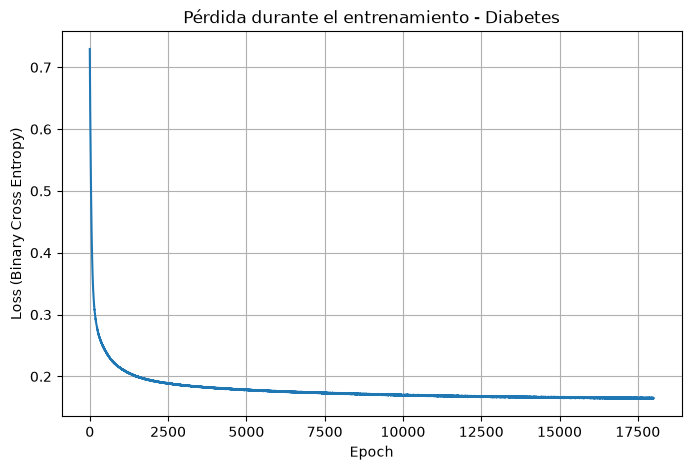

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(l_lab4)

plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.title("Pérdida durante el entrenamiento - Diabetes")
plt.grid()

plt.show()

In [23]:
from sklearn.metrics import accuracy_score

def evaluate_lab4(x):

    model.eval()

    # Forward
    logits = model(x)

    # Convertimos logits en probabilidades
    probabilidades = torch.sigmoid(logits)

    # Aplicamos umbral 0.5
    predicciones = (probabilidades >= 0.5).float()

    return predicciones

In [28]:
y_pred_lab4 = evaluate_lab4(X_test_lab4_t)

accuracy_lab4 = (
    (y_pred_lab4 == y_test_lab4_t.reshape(-1, 1))
    .float()
    .mean()
)

print(f"Accuracy: {accuracy_lab4.item() * 100:.2f}%")

Accuracy: 91.56%


In [29]:
# Evaluación sobre los datos de prueba
model.eval()

with torch.no_grad():

    logits_test_lab4 = model(X_test_lab4_t)

    # Convertimos logits en probabilidades
    probabilidades_test_lab4 = torch.sigmoid(logits_test_lab4)

    # Aplicamos umbral de 0.5
    predicciones_test_lab4 = (
        probabilidades_test_lab4 >= 0.5
    ).float()

# Mostramos algunas predicciones
for i in range(10):

    print(
        f"Real: {y_test_lab4_t[i].item():.0f} "
        f"| Probabilidad: {probabilidades_test_lab4[i].item():.4f} "
        f"| Predicción: {predicciones_test_lab4[i].item():.0f}"
    )

Real: 0 | Probabilidad: 0.2108 | Predicción: 0
Real: 1 | Probabilidad: 1.0000 | Predicción: 1
Real: 0 | Probabilidad: 0.1625 | Predicción: 0
Real: 0 | Probabilidad: 0.0939 | Predicción: 0
Real: 1 | Probabilidad: 1.0000 | Predicción: 1
Real: 0 | Probabilidad: 0.1788 | Predicción: 0
Real: 0 | Probabilidad: 0.2027 | Predicción: 0
Real: 1 | Probabilidad: 1.0000 | Predicción: 1
Real: 0 | Probabilidad: 0.2384 | Predicción: 0
Real: 1 | Probabilidad: 1.0000 | Predicción: 1
